# **CS715 - Project:  Structured Sparsification of Gated Recurrent Neural Networks**

## **Notebook-2: Sparse LSTM**

## **Step-1: Importing libraries and Loading data**

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import re
from collections import Counter

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:

train_df = pd.read_csv("/content/train.txt", sep=';', header=None, names=['text', 'emotion'])
val_df   = pd.read_csv("/content/val.txt", sep=';', header=None, names=['text', 'emotion'])
test_df  = pd.read_csv("/content/test.txt", sep=';', header=None, names=['text', 'emotion'])

## **Step-2: Label Encoding and Tokenization + vocab (same as baseline)**

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
all_emotions = pd.concat([train_df['emotion'], val_df['emotion'], test_df['emotion']])
label_encoder.fit(all_emotions)

train_df['label'] = label_encoder.transform(train_df['emotion'])
val_df['label']   = label_encoder.transform(val_df['emotion'])
test_df['label']  = label_encoder.transform(test_df['emotion'])


In [8]:
X_train = train_df['text'].tolist()
y_train = train_df['label'].tolist()

X_val = val_df['text'].tolist()
y_val = val_df['label'].tolist()

X_test = test_df['text'].tolist()
y_test = test_df['label'].tolist()


In [9]:
import re
from collections import Counter

def tokenize(text):
    # lower-case
    text = text.lower()
    # keep letters, numbers, apostrophes; replace others with space
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    # split on whitespace
    return text.split()


In [10]:
MAX_VOCAB_SIZE = 20000
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

counter = Counter()
for sent in X_train:
    counter.update(tokenize(sent))

most_common = counter.most_common(MAX_VOCAB_SIZE - 2)

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for i, (word, _) in enumerate(most_common, start=2):
    vocab[word] = i

print("Vocab size:", len(vocab))

Vocab size: 15214


In [11]:
import numpy as np

MAX_LEN = 50  # max tokens per sentence

def encode_sentence(text, vocab, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = [vocab.get(tok, vocab[UNK_TOKEN]) for tok in tokens]

    # pad or truncate
    if len(ids) < max_len:
        ids = ids + [vocab[PAD_TOKEN]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return np.array(ids, dtype=np.int64)


In [12]:
X_train_ids = np.stack([encode_sentence(t, vocab) for t in train_df['text']])
X_val_ids   = np.stack([encode_sentence(t, vocab) for t in val_df['text']])
X_test_ids  = np.stack([encode_sentence(t, vocab) for t in test_df['text']])

y_train_arr = np.array(train_df['label'], dtype=np.int64)
y_val_arr   = np.array(val_df['label'], dtype=np.int64)
y_test_arr  = np.array(test_df['label'], dtype=np.int64)


## **Step-3: Loading base LSTM model**

In [13]:
class EmotionLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (h_n, c_n) = self.lstm(embedded)
        last_hidden = h_n[-1]
        out = self.dropout(last_hidden)
        logits = self.fc(out)
        return logits

In [14]:
class EmotionDataset(Dataset):
    def __init__(self, X_ids, y_labels):
        self.X = torch.tensor(X_ids, dtype=torch.long)
        self.y = torch.tensor(y_labels, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_loader = DataLoader(EmotionDataset(X_train_ids, y_train_arr),
                          batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(EmotionDataset(X_val_ids, y_val_arr),
                        batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(EmotionDataset(X_test_ids, y_test_arr),
                         batch_size=BATCH_SIZE, shuffle=False)


In [15]:
vocab_size = len(vocab)
embed_dim = 100
hidden_dim = 128
num_classes = len(label_encoder.classes_)
pad_idx = vocab[PAD_TOKEN]

model = EmotionLSTM(vocab_size, embed_dim, hidden_dim, num_classes, pad_idx).to(device)
model.load_state_dict(torch.load("/content/emotion_lstm_baseline.pt"))
model.eval()

print("Baseline model loaded successfully!")

Baseline model loaded successfully!


## **Step-4: Inspecting LSTM params**

In [16]:
for name, param in model.lstm.named_parameters():
    print(name, param.shape)

weight_ih_l0 torch.Size([512, 100])
weight_hh_l0 torch.Size([512, 128])
bias_ih_l0 torch.Size([512])
bias_hh_l0 torch.Size([512])


In [17]:
# Get references to LSTM parameters
W_ih = model.lstm.weight_ih_l0.data.clone()   # (4H, input_dim)
W_hh = model.lstm.weight_hh_l0.data.clone()   # (4H, hidden_dim)
b_ih = model.lstm.bias_ih_l0.data.clone()     # (4H,)
b_hh = model.lstm.bias_hh_l0.data.clone()     # (4H,)

H = model.lstm.hidden_size
input_dim = model.lstm.input_size

print("Hidden size H:", H)
print("W_ih shape:", W_ih.shape)
print("W_hh shape:", W_hh.shape)

Hidden size H: 128
W_ih shape: torch.Size([512, 100])
W_hh shape: torch.Size([512, 128])


In [18]:
def gate_row_ranges(H):
    """
    Returns (i_rows, f_rows, g_rows, o_rows)
    where each is a slice object for that gate's rows.
    """
    i_rows = slice(0, H)
    f_rows = slice(H, 2*H)
    g_rows = slice(2*H, 3*H)
    o_rows = slice(3*H, 4*H)
    return i_rows, f_rows, g_rows, o_rows

i_rows, f_rows, g_rows, o_rows = gate_row_ranges(H)
print("i rows:", i_rows)
print("f rows:", f_rows)
print("g rows:", g_rows)
print("o rows:", o_rows)

i rows: slice(0, 128, None)
f rows: slice(128, 256, None)
g rows: slice(256, 384, None)
o rows: slice(384, 512, None)


## **Step-5: Weight Level Prening (W)**

In [19]:
weight_sparsity = 0.9  # 90% of smallest weights will be pruned

In [20]:
def prune_weights_global(W_ih, W_hh, sparsity):
    """
    Magnitude-based global pruning on W_ih and W_hh.
    Returns pruned copies (does not change original tensors).
    """
    # Flatten all weights together
    all_weights = torch.cat([W_ih.view(-1), W_hh.view(-1)])
    k = int((1.0 - sparsity) * all_weights.numel())  # number of weights to KEEP

    # Edge case: if k <= 0, just zero everything
    if k <= 0:
        W_ih_pruned = torch.zeros_like(W_ih)
        W_hh_pruned = torch.zeros_like(W_hh)
        threshold = 0.0
    else:
        # Get the |w| threshold such that only k largest remain
        topk_vals, _ = torch.topk(all_weights.abs(), k)
        threshold = topk_vals.min()  # everything below this will be zeroed

        # Apply mask
        W_ih_pruned = W_ih.clone()
        W_hh_pruned = W_hh.clone()
        W_ih_pruned[W_ih_pruned.abs() < threshold] = 0.0
        W_hh_pruned[W_hh_pruned.abs() < threshold] = 0.0

    return W_ih_pruned, W_hh_pruned, threshold

In [21]:
W_ih_pruned, W_hh_pruned, thr = prune_weights_global(W_ih, W_hh, weight_sparsity)

print("Global threshold:", float(thr))

nonzero_before = (W_ih.numel() + W_hh.numel())
nonzero_after = (W_ih_pruned.nonzero().size(0) + W_hh_pruned.nonzero().size(0))
print("Total weights before:", nonzero_before)
print("Total non-zero weights after pruning:", nonzero_after)
print("Effective sparsity:", 1 - nonzero_after / nonzero_before)


Global threshold: 0.18169131875038147
Total weights before: 116736
Total non-zero weights after pruning: 11673
Effective sparsity: 0.9000051398026316


In [22]:
# Make a new model with the same architecture
pruned_model = EmotionLSTM(vocab_size, embed_dim, hidden_dim, num_classes, pad_idx).to(device)

# Start from original baseline weights
pruned_model.load_state_dict(torch.load("/content/emotion_lstm_baseline.pt", map_location=device))

# Overwrite LSTM weights with pruned versions
with torch.no_grad():
    pruned_model.lstm.weight_ih_l0.copy_(W_ih_pruned)
    pruned_model.lstm.weight_hh_l0.copy_(W_hh_pruned)

pruned_model.eval()


EmotionLSTM(
  (embedding): Embedding(15214, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)

In [23]:
def compute_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).float().mean().item()

@torch.no_grad()
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_batches = 0
    criterion = nn.CrossEntropyLoss()  # no class weights here, just for evaluation

    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        acc = compute_accuracy(logits, batch_y)

        total_loss += loss.item()
        total_acc += acc
        total_batches += 1

    return total_loss / total_batches, total_acc / total_batches


In [24]:
# ========================================
# MULTI-SPARSITY EXPERIMENT (W-only pruning)
# ========================================

sparsity_levels = [0.1, 0.3, 0.5, 0.7, 0.8, 0.9]
results = []

for sp in sparsity_levels:
    print(f"\n=== Evaluating sparsity {int(sp*100)}% ===")

    # Step 1 — prune weights at this sparsity
    W_ih_sp, W_hh_sp, thr = prune_weights_global(W_ih, W_hh, sp)

    # Step 2 — reload baseline model (fresh)
    temp_model = EmotionLSTM(vocab_size, embed_dim, hidden_dim, num_classes, pad_idx).to(device)
    temp_model.load_state_dict(torch.load("/content/emotion_lstm_baseline.pt", map_location=device))

    # Step 3 — apply pruned weights
    with torch.no_grad():
        temp_model.lstm.weight_ih_l0.copy_(W_ih_sp)
        temp_model.lstm.weight_hh_l0.copy_(W_hh_sp)

    # Step 4 — evaluate
    test_loss, test_acc = evaluate(temp_model, test_loader, device)
    print(f"Sparsity={sp:.2f}, Test Accuracy={test_acc:.4f}")

    results.append((sp, test_acc))

# Print summary
print("\n=== FINAL RESULTS (Sparsity → Accuracy) ===")
for sp, acc in results:
    print(f"{int(sp*100)}% → {acc:.4f}")



=== Evaluating sparsity 10% ===
Sparsity=0.10, Test Accuracy=0.8276

=== Evaluating sparsity 30% ===
Sparsity=0.30, Test Accuracy=0.8257

=== Evaluating sparsity 50% ===
Sparsity=0.50, Test Accuracy=0.8110

=== Evaluating sparsity 70% ===
Sparsity=0.70, Test Accuracy=0.6982

=== Evaluating sparsity 80% ===
Sparsity=0.80, Test Accuracy=0.4585

=== Evaluating sparsity 90% ===
Sparsity=0.90, Test Accuracy=0.3447

=== FINAL RESULTS (Sparsity → Accuracy) ===
10% → 0.8276
30% → 0.8257
50% → 0.8110
70% → 0.6982
80% → 0.4585
90% → 0.3447


In [25]:
import pandas as pd

df_results = pd.DataFrame(results, columns=["sparsity", "accuracy"])
df_results["sparsity_percent"] = (df_results["sparsity"] * 100).astype(int)
df_results


,sparsity,accuracy,sparsity_percent
0,0.1,0.827637,10
1,0.3,0.825684,30
2,0.5,0.811035,50
3,0.7,0.698242,70
4,0.8,0.458496,80
5,0.9,0.344727,90


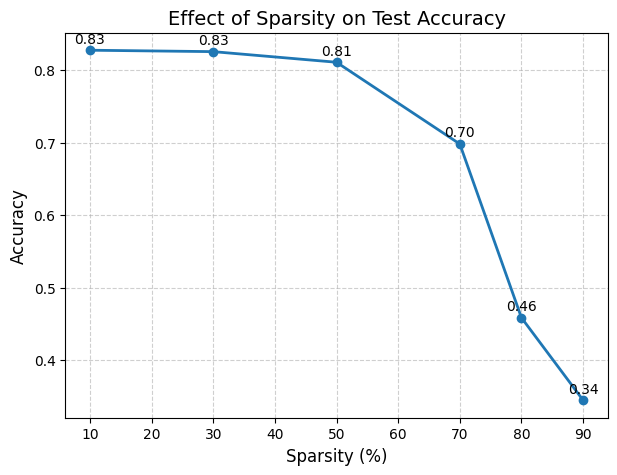

In [26]:
import matplotlib.pyplot as plt

sparsities_percent = df_results["sparsity"] * 100
accuracies = df_results["accuracy"]

plt.figure(figsize=(7,5))
plt.plot(sparsities_percent, accuracies, marker='o', linewidth=2)

plt.title("Effect of Sparsity on Test Accuracy", fontsize=14)
plt.xlabel("Sparsity (%)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

for x, y in zip(sparsities_percent, accuracies):
    plt.text(x, y + 0.01, f"{y:.2f}", ha='center', fontsize=10)

plt.show()
